<a href="https://colab.research.google.com/github/kirthikamanohar11-glitch/E-COMMERCE-RETURN-RATE-ANALYSIS/blob/main/Task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#load dataset
tf= pd.read_excel("/content/Book.xlsx")

In [3]:
#head
tf.head()

,invoice,stock code,description,quantity,invoice date,unit price,customer ID,country,customer ratings,discount percentage,delivery duration,product catogery
0,536378,84519A,TOMATO CHARLIE+LOLA COASTER SET,6,2010-01-12 09:37:00,2.95,14688,United Kingdom,9,70,6,kitchen & dining
1,536378,85183B,CHARLIE & LOLA WASTEPAPER BIN FLORA,48,2010-01-12 09:37:00,1.25,14688,United Kingdom,4,20,3,home organisation
2,536378,85071B,RED CHARLIE+LOLA PERSONAL DOORSIGN,96,2010-01-12 09:37:00,0.38,14688,United Kingdom,5,35,5,home decor
3,536378,21931,JUMBO STORAGE BAG SUKI,10,2010-01-12 09:37:00,1.95,14688,United Kingdom,6,80,4,storage and bags
4,536378,21929,JUMBO BAG PINK VINTAGE PAISLEY,10,2010-01-12 09:37:00,1.95,14688,United Kingdom,2,75,4,storage and bags


In [4]:
#dimension
tf.shape

(100, 12)

In [5]:
print("\nmissing values:")
print(tf.isnull().sum())
print("\n duplicate rows:")
print(tf.duplicated().sum())


missing values:
invoice                0
stock code             0
description            0
quantity               0
invoice date           0
unit price             0
customer ID            0
country                0
customer ratings       0
discount percentage    0
delivery duration      0
product catogery       0
dtype: int64

 duplicate rows:
0


In [6]:
total_orders= len(tf)
returned_orders=(tf['quantity']<0).sum()

return_percentage=(returned_orders/total_orders)*100

print("\ntotal orders:",total_orders)
print("returned orders:", returned_orders)
print("returned percentage:",return_percentage)


total orders: 100
returned orders: 2
returned percentage: 2.0


In [7]:
#statistics
print("\n product price statistics")
print(tf['unit price'].describe())


 product price statistics
count    100.000000
mean       3.865600
std        4.270923
min        0.380000
25%        1.450000
50%        2.550000
75%        4.725000
max       27.500000
Name: unit price, dtype: float64


In [8]:
tf.columns = tf.columns.str.strip()

print("\n average delivery duration")
print(tf['delivery duration'].mean())

print("\n average customer rating")
print(tf['customer ratings'].mean())


 average delivery duration
4.43

 average customer rating
5.56


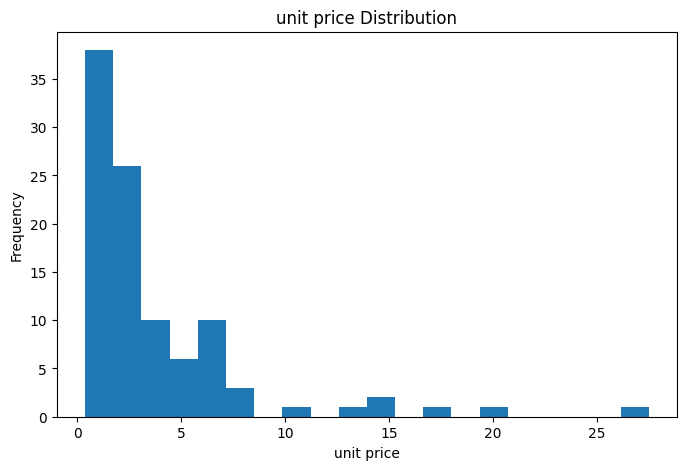

In [9]:
from matplotlib import pyplot as plt
# Histogram
plt.figure(figsize=(8,5))
plt.hist(tf['unit price'], bins=20)
plt.title("unit price Distribution")
plt.xlabel("unit price")
plt.ylabel("Frequency")
plt.show()


Return Rate by Category:
product catogery
crafts and party supplies      0.000000
educational toys               0.000000
fashion accessories            0.000000
home decor                     2.941176
home furnishing                0.000000
home organisation              0.000000
kitchen & dining               0.000000
lighting                       0.000000
outdoor and garden             0.000000
promotion/discount           100.000000
seasonal and christmas         0.000000
storage and bags               0.000000
tools and DIY                  0.000000
toys and gifts                 0.000000
Name: returned, dtype: float64


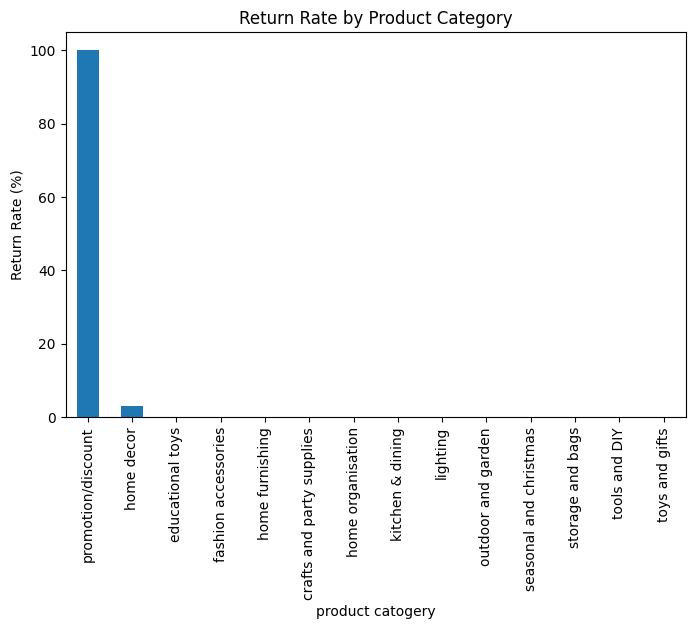

In [10]:
# Category vs Return Rate
tf['returned']=(tf['quantity']<0).astype(int)
category_return = (tf['returned']).groupby(tf['product catogery']).mean() * 100

print("\nReturn Rate by Category:")
print(category_return)

plt.figure(figsize=(8,5))
category_return.sort_values(ascending=False).plot(kind='bar')
plt.title("Return Rate by Product Category")
plt.xlabel("product catogery")
plt.ylabel("Return Rate (%)")
plt.show()

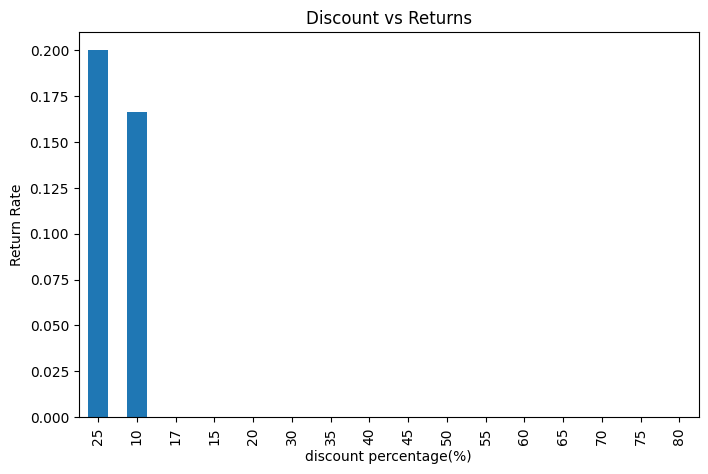

In [11]:
import matplotlib.pyplot as plt

tf['returned'] = (tf['quantity'] < 0).astype(int)
plt.figure(figsize=(8,5))
tf.groupby('discount percentage')['returned'].mean().sort_values(ascending=False).plot(kind='bar')

plt.xlabel('discount percentage(%)')
plt.ylabel('Return Rate')
plt.title('Discount vs Returns')
plt.show()

In [12]:
category_return = tf.groupby('product catogery')['returned'].mean()*100

print(category_return)

category_return.sort_values(ascending=False)

product catogery
crafts and party supplies      0.000000
educational toys               0.000000
fashion accessories            0.000000
home decor                     2.941176
home furnishing                0.000000
home organisation              0.000000
kitchen & dining               0.000000
lighting                       0.000000
outdoor and garden             0.000000
promotion/discount           100.000000
seasonal and christmas         0.000000
storage and bags               0.000000
tools and DIY                  0.000000
toys and gifts                 0.000000
Name: returned, dtype: float64


,returned
product catogery,
promotion/discount,100.000000
home decor,2.941176
educational toys,0.000000
fashion accessories,0.000000
home furnishing,0.000000
crafts and party supplies,0.000000
home organisation,0.000000
kitchen & dining,0.000000
lighting,0.000000


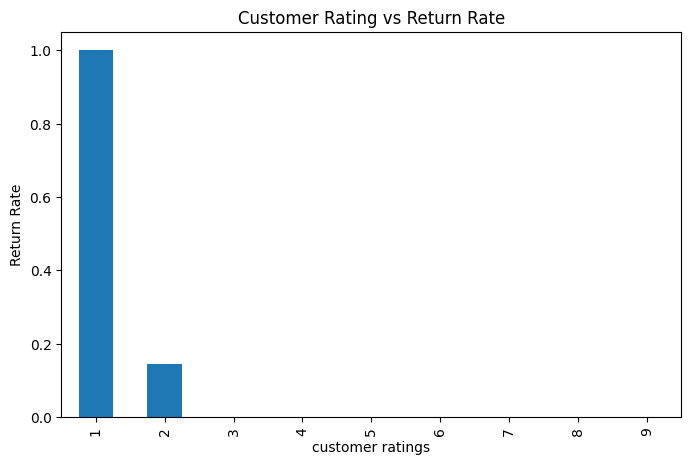

In [13]:
plt.figure(figsize=(8,5))
tf.groupby('customer ratings')['returned'].mean().plot(kind='bar')
plt.ylabel('Return Rate')
plt.title('Customer Rating vs Return Rate')
plt.show()

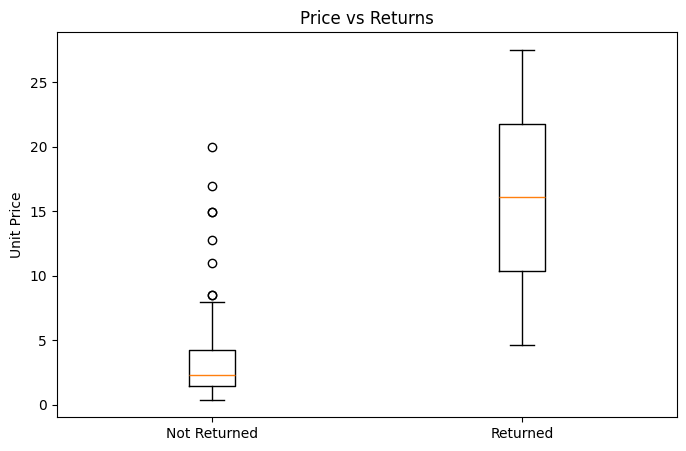

In [14]:
plt.figure(figsize=(8,5))
plt.boxplot([tf[tf['returned']==0]['unit price'], tf[tf['returned']==1]['unit price']])

plt.xticks([1,2],['Not Returned','Returned'])
plt.ylabel('Unit Price')
plt.title('Price vs Returns')
plt.show()

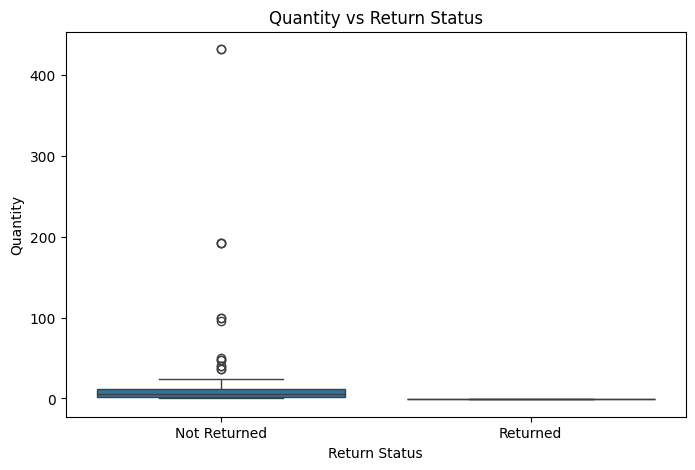

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    x='returned',
    y='quantity',
    data=tf
)

plt.title('Quantity vs Return Status')
plt.xlabel('Return Status')
plt.ylabel('Quantity')

plt.xticks([0,1], ['Not Returned', 'Returned'])

plt.show()

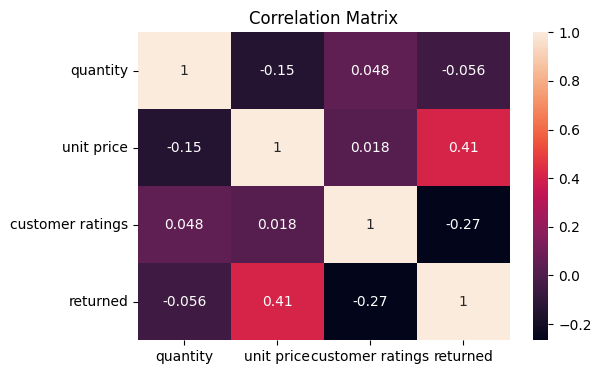

In [16]:
import seaborn as sns

plt.figure(figsize=(6,4))

sns.heatmap(
    tf[['quantity','unit price','customer ratings','returned']].corr(),
    annot=True
)

plt.title("Correlation Matrix")
plt.show()

In [17]:
Q1 = tf['unit price'].quantile(0.25)
Q3 = tf['unit price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = tf[(tf['unit price'] < lower) |
              (tf['unit price'] > upper)]

print(outliers)

    invoice stock code                          description  quantity  \
41  C536379          D                             Discount        -1   
51   536382      22839      3 TIER CAKE TIN GREEN AND CREAM         2   
52   536382      22838        3 TIER CAKE TIN RED AND CREAM         2   
53   536382      22783     SET 3 WICKER OVAL BASKETS W LIDS         4   
63   536384      21340  CLASSIC METAL BIRDCAGE PLANT HOLDER         2   
67   536384      22424               ENAMEL BREAD BIN CREAM         8   
68   536385      22783     SET 3 WICKER OVAL BASKETS W LIDS         1   

          invoice date  unit price  customer ID         country  \
41 2010-01-12 09:41:00       27.50        14527  United Kingdom   
51 2010-01-12 09:45:00       14.95        16098  United Kingdom   
52 2010-01-12 09:45:00       14.95        16098  United Kingdom   
53 2010-01-12 09:45:00       16.95        16098  United Kingdom   
63 2010-01-12 09:53:00       12.75        18074  United Kingdom   
67 2010-01-12

In [18]:
from scipy.stats import chi2_contingency
import pandas as pd

# Step 1: Create Contingency Table
contingency_table = pd.crosstab( tf['product catogery'],
    tf['returned'])

print("Contingency Table")
print(contingency_table)

# Step 2: Perform Chi-Square Test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

# Step 3: Display Results
print("\nChi-Square Test Results")
print("result:")
print(f"Chi-Square Statistic : {chi2:.4f}")
print(f"P-Value              : {p_value:.4f}")
print(f"Degrees of Freedom   : {dof}")

# Step 4: Decision Rule
alpha = 0.05

print("\nHypothesis Testing")

if p_value < alpha:
    print("Decision: Reject H₀")
    print("Conclusion: Product Category significantly influences Return Behavior.")
else:
    print("Decision: Fail to Reject H₀")
    print("Conclusion: No significant relationship was found between Product Category and Return Behavior.")

Contingency Table
returned                    0  1
product catogery                
crafts and party supplies   1  0
educational toys            1  0
fashion accessories         1  0
home decor                 33  1
home furnishing             6  0
home organisation           2  0
kitchen & dining           17  0
lighting                    8  0
outdoor and garden          4  0
promotion/discount          0  1
seasonal and christmas      4  0
storage and bags           13  0
tools and DIY               1  0
toys and gifts              7  0

Chi-Square Test Results
result:
Chi-Square Statistic : 50.4802
P-Value              : 0.0000
Degrees of Freedom   : 13

Hypothesis Testing
Decision: Reject H₀
Conclusion: Product Category significantly influences Return Behavior.


In [19]:
def rating_group(rating):
    if rating <= 3:
        return 'Low Rating'
    elif rating <= 6:
        return 'Medium Rating'
    else:
        return 'High Rating'

tf['rating_segment'] = tf['customer ratings'].apply(rating_group)
display(tf.head())

,invoice,stock code,description,quantity,invoice date,unit price,customer ID,country,customer ratings,discount percentage,delivery duration,product catogery,returned,rating_segment
0,536378,84519A,TOMATO CHARLIE+LOLA COASTER SET,6,2010-01-12 09:37:00,2.95,14688,United Kingdom,9,70,6,kitchen & dining,0,High Rating
1,536378,85183B,CHARLIE & LOLA WASTEPAPER BIN FLORA,48,2010-01-12 09:37:00,1.25,14688,United Kingdom,4,20,3,home organisation,0,Medium Rating
2,536378,85071B,RED CHARLIE+LOLA PERSONAL DOORSIGN,96,2010-01-12 09:37:00,0.38,14688,United Kingdom,5,35,5,home decor,0,Medium Rating
3,536378,21931,JUMBO STORAGE BAG SUKI,10,2010-01-12 09:37:00,1.95,14688,United Kingdom,6,80,4,storage and bags,0,Medium Rating
4,536378,21929,JUMBO BAG PINK VINTAGE PAISLEY,10,2010-01-12 09:37:00,1.95,14688,United Kingdom,2,75,4,storage and bags,0,Low Rating
